# **Baskın Renkler için Histogramlar ve K-Means Kümeleme**

#### **Bu derste şunları öğreneceğiz:**
1. Görüntülerin RGB Histogram gösterimlerini görüntüleme
2. Görüntülerdeki baskın renkleri ve oranlarını elde etmek için K-Means Kümelemesini kullanma


In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt


def imshow(title = "Image", image = None, size = 8):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w/h
    plt.figure(figsize=(size * aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()

## Kullanım:

hist=cv2.calcHist(images, channels, mask, histSize, ranges, accumulate=False)

##  Parametreler
1. images: Liste olarak verilir: [image], Girdi görüntüsü (gri tonlamalı veya renkli olabilir).
2. channels: Hangi kanalların histogramının alınacağını belirtir. 
[0] → Mavi kanal, [1] → Yeşil kanal, [2] → Kırmızı kanal (BGR için).
Gri tonlamalı görüntü için [0] kullanılır.
3. mask: None olursa tüm görüntünün histogramı hesaplanır.
Belirli bir bölgenin histogramını almak için maske kullanılabilir.
4. histSize: Bin(sütun) sayısı. [256] → 0–255 arası her değer için bir bin (sütun).
5. ranges: Piksel değer aralığı. [0, 256] genellikle kullanılır.
6. accumulate (isteğe bağlı, varsayılan False). True ise histogram önceki hesaplamaların üzerine eklenir. False ise sıfırdan hesaplanır.

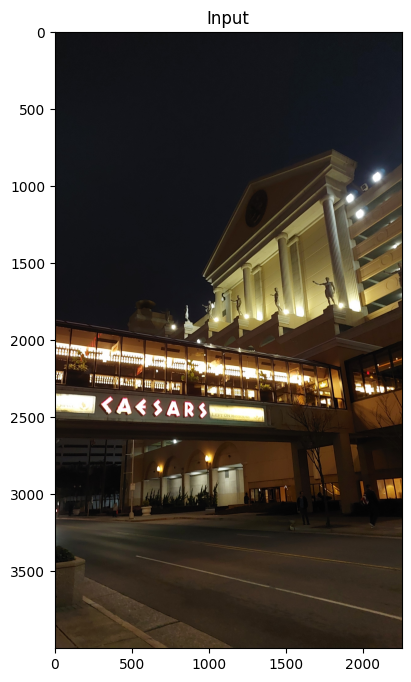

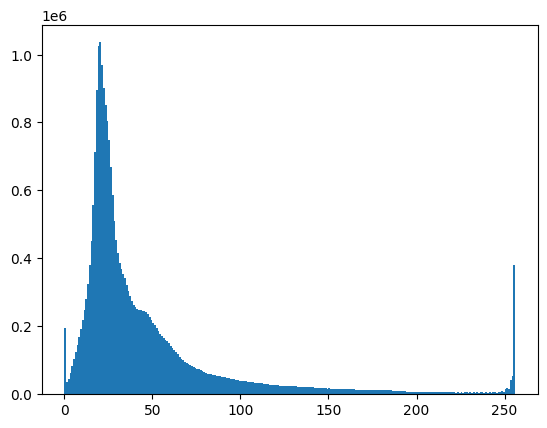

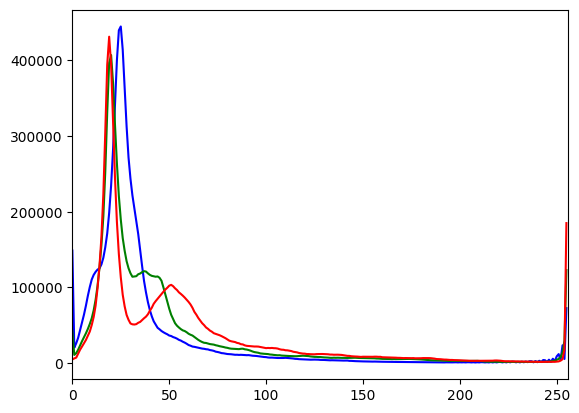

In [2]:
image = cv2.imread('../files/images/america23.jpg')
imshow("Input", image)

# Bir histogram çiziyoruz, ravel() görüntü dizimizi düzleştiriyor
plt.hist(image.ravel(), bins=256, range=(0, 256))
plt.show()
#Histogram, görüntüde hangi parlaklık değerlerinden ne kadar bulunduğunu gösterir.Örneğin:
#Sol tarafa yığılmışsa görüntü karanlık,
#Sağ tarafa yığılmışsa görüntü aydınlıktır,
#Geniş bir dağılım varsa kontrast yüksektir.

# Renk Kanallarını Görüntüleme
color = ('b', 'g', 'r')

#plt.plot fonksiyonunda çizgi rengi birkaç farklı şekilde belirlenebilir:
# 1. Kısa Renk Kodları 'b' → mavi 'g' → yeşil 'r' → kırmızı 'c' → camgöbeği (cyan) 'm' → mor (magenta) 'y' → sarı 'k' → siyah 'w' → beyaz
# 2. RGB veya RGBA Değerleri (0–1 Arası) plt.plot(data, color=(0.1, 0.5, 0.8)) RGB.  
# plt.plot(data, color=(0.1, 0.5, 0.8, 0.7))  # RGBA (alpha=0.7 saydamlık)
# 3. Hex Kodları plt.plot(data, color='#FF5733')  # turuncu ton


# Şimdi renkleri ayırıyoruz ve her birini Histogramda çiziyoruz
for i, col in enumerate(color):
    histogram2 = cv2.calcHist([image], [i], None, [256], [0, 256])
    plt.plot(histogram2, color = col)
    plt.xlim([0,256])
    
plt.show()

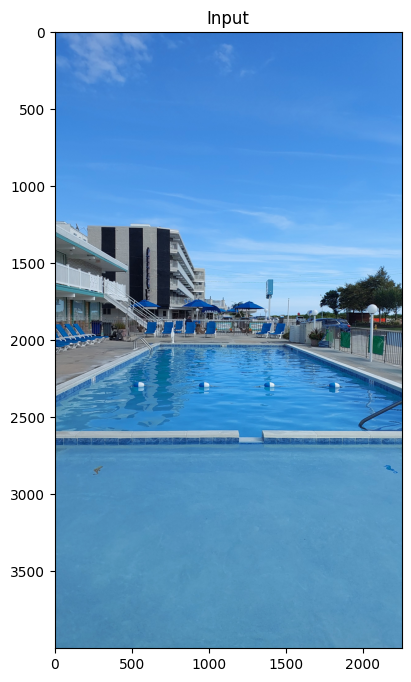

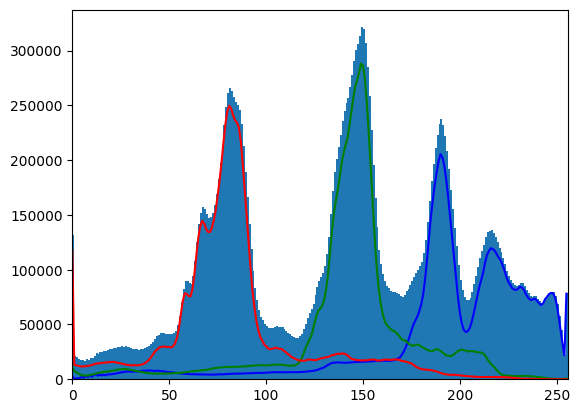

In [3]:
image = cv2.imread('../files/images/america24.jpg')
imshow("Input", image)

histogram = cv2.calcHist([image], [0], None, [256], [0, 256])

# Bir histogram çiziyoruz, ravel() görüntü dizimizi düzleştiriyor

plt.hist(image.ravel(), bins=256, range=(0, 256))
# Ayrı Renk Kanallarını Görüntüleme
color = ('b', 'g', 'r')

# Şimdi renkleri ayırıyoruz ve her birini Histogramda çiziyoruz
for i, col in enumerate(color):
    histogram2 = cv2.calcHist([image], [i], None, [256], [0, 256])
    plt.plot(histogram2, color = col)
    plt.xlim([0,256])
    
plt.show()

## **Bir görüntüdeki baskın renkleri elde etmek için K-Means Kümeleme**

In [4]:
def centroidHistogram(clt):
    # Her kümedeki piksellere dayalı olarak kümeler için bir histrogram oluşturun
    # Her küme için etiketleri alın
    numLabels = np.arange(0, len(np.unique(clt.labels_)) + 1)

    # Create our histogram 
    (hist, _) = np.histogram(clt.labels_, bins = numLabels)

    # normalize the histogram, so that it sums to one
    hist = hist.astype("float")
    hist /= hist.sum()

    return hist

def plotColors(hist, centroids):
    # Create our blank barchart
    bar = np.zeros((100, 500, 3), dtype = "uint8")

    x_start = 0
    # iterate over the percentage and dominant color of each cluster
    for (percent, color) in zip(hist, centroids):
      # plot the relative percentage of each cluster
      end = x_start + (percent * 500)
      cv2.rectangle(bar, (int(x_start), 0), (int(end), 100),
        color.astype("uint8").tolist(), -1)
      x_start = end
    return bar

In [5]:
#python ortamında (bilgisayarınızda) scikit-learn kütüphanesi yüklü değilse
!pip install scikit-learn

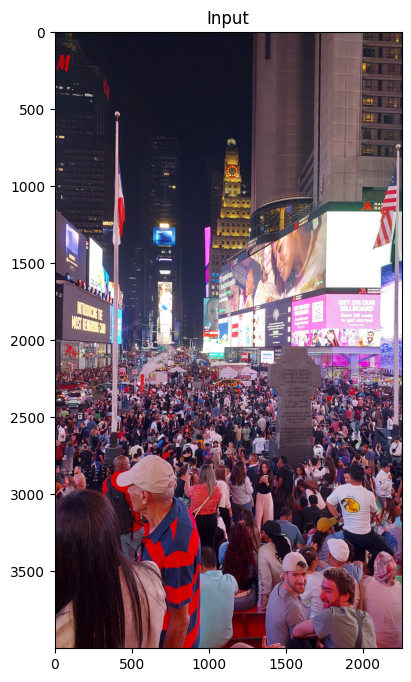

(4000, 2252, 3)
(9008000, 3)


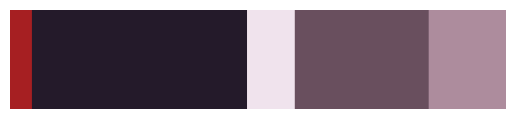

In [6]:
from sklearn.cluster import KMeans

image = cv2.imread('../files/images/america25.jpg')
imshow("Input", image)

# Görüntümüzü RGB piksellerinin bir listesi olarak yeniden şekillendiriyoruz
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
print(image.shape)
image = image.reshape((image.shape[0] * image.shape[1], 3))
print(image.shape)

number_of_clusters = 5
clt = KMeans(number_of_clusters)
clt.fit(image)
#K-Means, piksel renklerini number_of_clusters kadar gruba ayırır.
#Her grup için:
#Merkez (cluster center) = O gruptaki piksellerin ortalama RGB değeri.
#Yani renk paletinde gördüğün renk, küme ortalamasıdır, birebir görüntüdeki en çok tekrar eden pikselin rengi değil.
#Ancak histogramdaki çubuğun genişliği, o rengin görüntüdeki oranını gösterir.

hist = centroidHistogram(clt)
bar = plotColors(hist, clt.cluster_centers_)

#Renk çubuklarımızı gösterin
plt.figure()
plt.axis("off")
plt.imshow(bar)
plt.show()

### **Başka bir görüntü deneyelim**

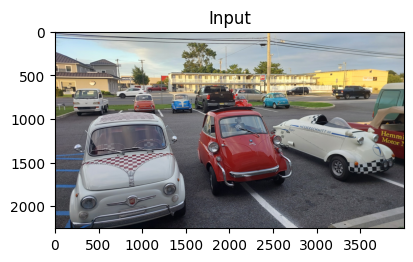

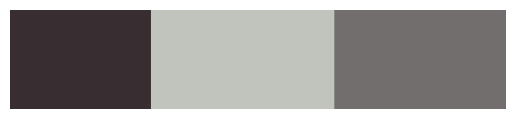

In [7]:
from sklearn.cluster import KMeans

image = cv2.imread('../files/images/america26.jpg')
imshow("Input", image)

# Görüntümüzü RGB piksellerinin bir listesi olarak yeniden şekillendiriyoruz
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = image.reshape((image.shape[0] * image.shape[1], 3))

number_of_clusters = 3
clt = KMeans(number_of_clusters)
clt.fit(image)

hist = centroidHistogram(clt)
bar = plotColors(hist, clt.cluster_centers_)

#Renk çubuklarımızı gösterin
plt.figure()
plt.axis("off")
plt.imshow(bar)
plt.show()